# TP 0 — Understanding K-Nearest Neighbors (KNN)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/L2Math/blob/main/session2/tp_0_knn.ipynb)

## Objectives
1. Understand the KNN algorithm and its intuition
2. Visualize how different distance metrics work
3. Explore the effect of $k$ on classification decision boundaries
4. Learn how to choose $k$ using a validation curve
5. Apply KNN to regression problems
6. Understand why feature scaling matters for distance-based methods
7. Discover the curse of dimensionality

## Setup

Run the cell below to install and import the required packages.

In [1]:
!pip install git+https://github.com/racousin/L2Math.git

  Cloning https://github.com/racousin/L2Math.git to /private/var/folders/n1/bdjyqqwn5t5cglz8mdg_13900000gn/T/pip-req-build-ultywit6
  Running command git clone --filter=blob:none --quiet https://github.com/racousin/L2Math.git /private/var/folders/n1/bdjyqqwn5t5cglz8mdg_13900000gn/T/pip-req-build-ultywit6
  Resolved https://github.com/racousin/L2Math.git to commit 78791a0cc40b11b840c58ef8db9096f62af18e21
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for l2math: filename=l2math-0.1.0-py3-none-any.whl size=5376 sha256=741597eee2601e44eafe78bd84c1101c875f2e73595cde650bdc00f05471aaf7
  Stored in directory: /private/var/folders/n1/bdjyqqwn5t5cglz8mdg_13900000gn/T/pip-ephem-wheel-cache-1oxtveoa/wheels/3d/e5/68/8b33a041bfa94338f98eaa2a6129eb4738d5680ac4f2af267a
Successfully built l2math
  Attempting uninstall: l2math
    Found existing installation: l2math 0.1.0
    Uninstalling l2math-0.1.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from l2math import plot_decision_boundary_2d

print("Setup complete!")

ImportError: cannot import name 'plot_decision_boundary_2d' from 'l2math' (/Users/raphaelcousin/Library/Caches/pypoetry/virtualenvs/l2math-yynCEu44-py3.13/lib/python3.13/site-packages/l2math/__init__.py)

---
# Part 1: The KNN Algorithm

## Intuition

*"Tell me who your neighbors are, and I will tell you who you are."*

KNN is one of the simplest machine learning algorithms. The idea is straightforward:
to predict the label of a new point, look at the $k$ closest points in the training data and let them **vote**.

## Step by Step

Given a new query point $x_q$:

1. **Compute distances** between $x_q$ and every point in the training set
2. **Find the $k$ nearest neighbors** — the $k$ training points closest to $x_q$
3. **Aggregate their labels:**
   - *Classification:* majority vote among the $k$ neighbors
   - *Regression:* average of the $k$ neighbors' target values

## A "Lazy Learner"

KNN has **no training phase**. It simply stores the training data and does all the work at prediction time.
This is why it is called a *lazy learner* — it defers computation until a query is made.

---
# Part 2: Distance Metrics

The choice of distance metric determines what "closeness" means. Two common metrics are:

**Euclidean distance** ($p = 2$):
$$d(x, x') = \sqrt{\sum_{i} (x_i - x'_i)^2}$$

**Manhattan distance** ($p = 1$):
$$d(x, x') = \sum_{i} |x_i - x'_i|$$

Both are special cases of the **Minkowski distance** with parameter $p$:
$$d_p(x, x') = \left(\sum_{i} |x_i - x'_i|^p\right)^{1/p}$$

The unit ball $\{x : d_p(0, x) \le 1\}$ looks different for each $p$.

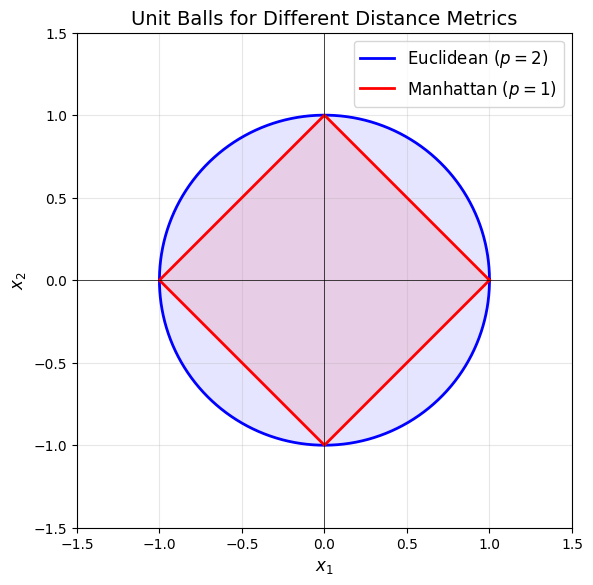

In [3]:
# Visualize unit balls for Euclidean (p=2) and Manhattan (p=1)
t = np.linspace(0, 2 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(6, 6))

# Euclidean unit circle: |x|^2 + |y|^2 = 1 -> parametric: (cos t, sin t)
x_euclid = np.cos(t)
y_euclid = np.sin(t)
ax.plot(x_euclid, y_euclid, 'b-', linewidth=2, label='Euclidean ($p=2$)')
ax.fill(x_euclid, y_euclid, color='blue', alpha=0.1)

# Manhattan unit circle: |x|^1 + |y|^1 = 1 -> parametric: (sign(cos t)*|cos t|^(2/p), ...)
# For p=1: x = sign(cos t) * |cos t|^2, y = sign(sin t) * |sin t|^2
p = 1
x_manhattan = np.sign(np.cos(t)) * np.abs(np.cos(t)) ** (2.0 / p)
y_manhattan = np.sign(np.sin(t)) * np.abs(np.sin(t)) ** (2.0 / p)
ax.plot(x_manhattan, y_manhattan, 'r-', linewidth=2, label='Manhattan ($p=1$)')
ax.fill(x_manhattan, y_manhattan, color='red', alpha=0.1)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Unit Balls for Different Distance Metrics', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

The Euclidean unit ball is a circle, while the Manhattan unit ball is a diamond (rotated square).
This means that under Manhattan distance, moving diagonally is "more expensive" than moving along axes.

---
# Part 3: KNN Classification on 2D Data

Let's see how KNN works on a non-linearly separable dataset. We generate the classic **moons** dataset and observe how the decision boundary changes as we vary $k$.

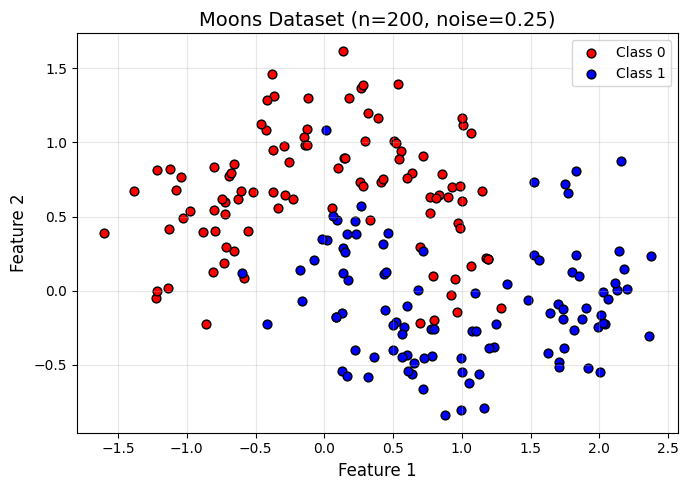

In [4]:
# Generate the moons dataset
X_moons, y_moons = make_moons(n_samples=200, noise=0.25, random_state=42)

# Visualize the raw data
plt.figure(figsize=(7, 5))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1],
            c='red', edgecolors='k', s=40, label='Class 0')
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1],
            c='blue', edgecolors='k', s=40, label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Moons Dataset (n=200, noise=0.25)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'plot_decision_boundary_2d' is not defined

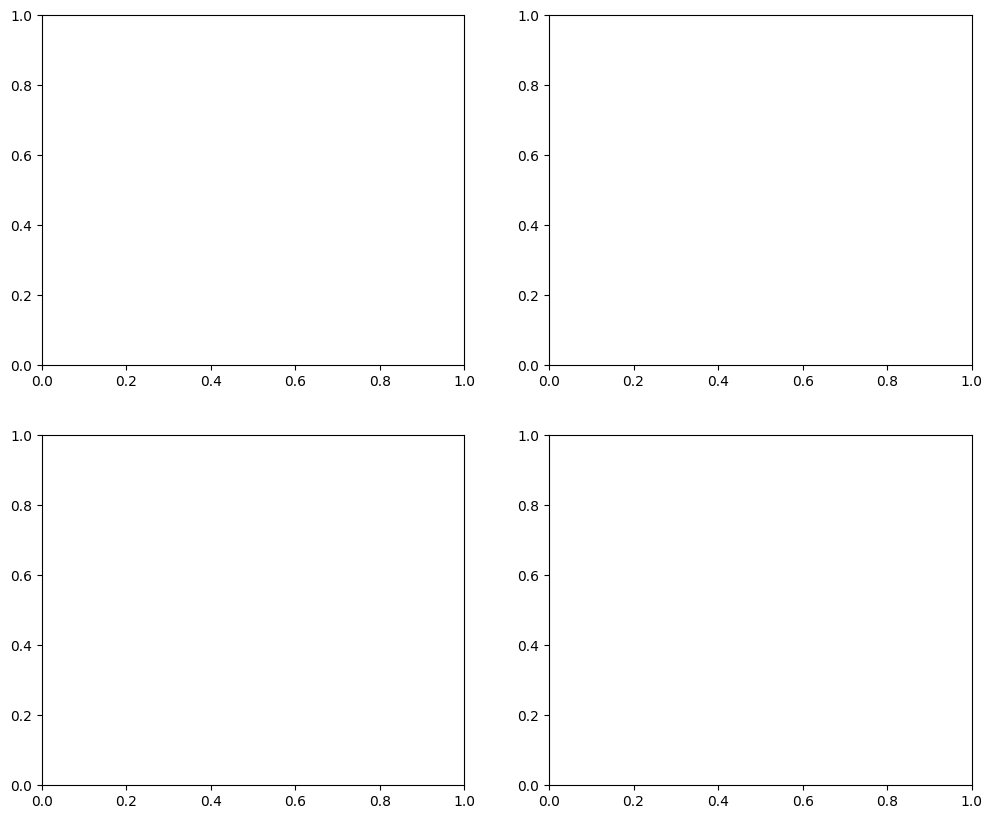

In [5]:
# Decision boundaries for different values of k
k_values = [1, 5, 20, 50]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_moons, y_moons)
    train_acc = accuracy_score(y_moons, knn.predict(X_moons))
    plot_decision_boundary_2d(
        knn, X_moons, y_moons,
        title=f'k = {k}  (train acc = {train_acc:.2f})',
        ax=axes[idx]
    )

plt.suptitle('Effect of k on KNN Decision Boundary', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Key Insight:**

- **Small $k$ (e.g., $k=1$):** The decision boundary is very complex and follows every data point closely. This leads to **overfitting** — the model memorizes noise in the training data.
- **Large $k$ (e.g., $k=50$):** The decision boundary is very smooth, almost linear. This leads to **underfitting** — the model is too simple to capture the true shape of the data.
- **The right $k$** strikes a balance between these two extremes.

---
# Part 4: Choosing $k$ — Validation Curve

How do we find the best value of $k$? We split the data into training and test sets, then evaluate accuracy for a range of $k$ values.

In [ ]:
np.random.seed(42)

# Split the moons data
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

# Evaluate for k = 1 to 50
k_range = range(1, 51)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

# Find the best k
best_k = k_range[np.argmax(test_accuracies)]
best_acc = max(test_accuracies)

# Plot the validation curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_accuracies, 'b-o', markersize=3, label='Train accuracy')
ax.plot(k_range, test_accuracies, 'r-o', markersize=3, label='Test accuracy')
ax.axvline(x=best_k, color='green', linestyle='--', alpha=0.7,
           label=f'Best k = {best_k} (test acc = {best_acc:.2f})')
ax.set_xlabel('k (number of neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Validation Curve: Train and Test Accuracy vs k', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best k: {best_k} with test accuracy: {best_acc:.2f}")

Notice that:
- At $k=1$, train accuracy is **perfect** (1.0) because each point is its own nearest neighbor.
- As $k$ increases, train accuracy decreases (the model becomes less flexible).
- Test accuracy rises, reaches a peak (the sweet spot), then drops as the model underfits.

---
# Part 5: KNN Regression

KNN also works for regression: instead of a majority vote, the prediction is the **average** of the $k$ nearest neighbors' target values.

$$\hat{y}(x_q) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(x_q)} y_i$$

Let's see how $k$ affects regression predictions on a noisy sine curve.

In [ ]:
np.random.seed(42)

# Generate noisy sine data
X_reg = np.sort(np.random.uniform(0, 2 * np.pi, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.3, 100)

# Dense grid for smooth prediction line
X_plot = np.linspace(0, 2 * np.pi, 500).reshape(-1, 1)

k_values_reg = [1, 5, 20]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, k in enumerate(k_values_reg):
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_reg, y_reg)
    y_pred_plot = knn_reg.predict(X_plot)

    axes[idx].scatter(X_reg, y_reg, c='blue', alpha=0.4, s=20, label='Data')
    axes[idx].plot(X_plot, y_pred_plot, 'r-', linewidth=2, label=f'KNN (k={k})')
    axes[idx].plot(X_plot, np.sin(X_plot), 'g--', linewidth=1, alpha=0.5, label='True $\sin(x)$')
    axes[idx].set_xlabel('$x$', fontsize=12)
    axes[idx].set_ylabel('$y$', fontsize=12)
    axes[idx].set_title(f'k = {k}', fontsize=13)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('KNN Regression: Effect of k on Prediction Smoothness', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

**Key Insight:**

- At $k=1$, the prediction curve is jagged and passes through every training point (interpolation).
- As $k$ increases, the predictions become smoother because each prediction averages over more neighbors.
- Too large a $k$ would flatten the curve and lose the underlying sine pattern.

---
# Part 6: Effect of Feature Scaling

KNN relies on distances. If one feature has a much larger range than another, it will dominate the distance computation and the other feature will be effectively ignored.

**Example:** Feature 1 lives in $[0, 1]$ while Feature 2 lives in $[0, 1000]$.

In [ ]:
np.random.seed(42)

# Generate classification data
X_scale, y_scale = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, random_state=42
)

# Rescale to [0, 1] first
X_scale[:, 0] = (X_scale[:, 0] - X_scale[:, 0].min()) / (X_scale[:, 0].max() - X_scale[:, 0].min())
X_scale[:, 1] = (X_scale[:, 1] - X_scale[:, 1].min()) / (X_scale[:, 1].max() - X_scale[:, 1].min())

# Now blow up Feature 2 by factor 1000
X_unscaled = X_scale.copy()
X_unscaled[:, 1] = X_unscaled[:, 1] * 1000

# StandardScaler on the unscaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

# Fit KNN on both
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_unscaled, y_scale)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_scaled, y_scale)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary_2d(
    knn_unscaled, X_unscaled, y_scale,
    title='Before Scaling (Feature 2 in [0, 1000])',
    ax=axes[0]
)

plot_decision_boundary_2d(
    knn_scaled, X_scaled, y_scale,
    title='After StandardScaler',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

**Why does this happen?**

Without scaling, the Euclidean distance is dominated by Feature 2 (range $[0, 1000]$), making Feature 1 (range $[0, 1]$) almost irrelevant. The decision boundary becomes nearly vertical — the model only "sees" Feature 2.

After applying `StandardScaler` (zero mean, unit variance), both features contribute equally to the distance. The decision boundary now reflects the true structure of the data.

**Rule of thumb:** Always scale your features before using KNN (or any distance-based algorithm).

---
# Part 7: The Curse of Dimensionality

KNN relies on the notion that nearby points have similar labels. But in high dimensions, a surprising phenomenon occurs: **all points become approximately equidistant**.

To measure this, we compute the ratio:

$$\rho = \frac{d_{\text{nearest}}}{d_{\text{farthest}}}$$

When $\rho \to 1$, the nearest and farthest points are almost equally far away, making KNN meaningless.

In [ ]:
np.random.seed(42)

dimensions = [2, 5, 10, 20, 50, 100, 500, 1000]
n_points = 500
n_queries = 100

mean_ratios = []
std_ratios = []

for d in dimensions:
    # Random points in d dimensions (uniform in [0, 1]^d)
    data = np.random.uniform(0, 1, size=(n_points, d))
    queries = np.random.uniform(0, 1, size=(n_queries, d))

    ratios = []
    for q in queries:
        # Euclidean distances from query to all data points
        dists = np.sqrt(np.sum((data - q) ** 2, axis=1))
        ratio = dists.min() / dists.max()
        ratios.append(ratio)

    mean_ratios.append(np.mean(ratios))
    std_ratios.append(np.std(ratios))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(dimensions, mean_ratios, yerr=std_ratios, fmt='bo-',
            capsize=4, linewidth=2, markersize=7, label='Mean ratio')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='$\\rho = 1$ (all equidistant)')
ax.set_xscale('log')
ax.set_xlabel('Number of Dimensions', fontsize=12)
ax.set_ylabel('$d_{\\mathrm{nearest}} \; / \; d_{\\mathrm{farthest}}$', fontsize=13)
ax.set_title('Curse of Dimensionality: Distance Ratio vs Number of Dimensions', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("Mean distance ratio (nearest / farthest):")
for d, r in zip(dimensions, mean_ratios):
    print(f"  d = {d:>4d}:  ratio = {r:.4f}")

**Observation:** As the number of dimensions increases, the ratio $\rho = d_{\text{nearest}} / d_{\text{farthest}}$ converges toward 1. This means:

- In high dimensions, the nearest neighbor is almost as far as the farthest one.
- The concept of "closeness" breaks down.
- KNN predictions become essentially random because all neighbors are equally (un)informative.

This is the **curse of dimensionality**. It is a fundamental limitation of distance-based methods and one reason why dimensionality reduction techniques (PCA, feature selection) are important.

---
# Summary

## When to Use KNN

- Small to medium-sized datasets
- Low to moderate dimensionality
- Non-linear decision boundaries needed without complex models
- When you want a simple, interpretable baseline

## Pros and Cons

| **Pros** | **Cons** |
|---|---|
| Simple to understand and implement | Slow at prediction time (must compute all distances) |
| No training phase | Memory-intensive (stores entire training set) |
| Naturally handles multi-class problems | Sensitive to irrelevant features |
| Non-parametric (makes no assumptions about data distribution) | Sensitive to feature scaling |
| Can model complex, non-linear boundaries | Suffers from the curse of dimensionality |

## Key Takeaways

1. **$k$ controls the bias-variance tradeoff:** small $k$ = low bias, high variance; large $k$ = high bias, low variance.
2. **Always scale your features** before applying KNN.
3. **KNN degrades in high dimensions** — consider dimensionality reduction first.
4. Use a **validation curve** to choose the best $k$.